# Análisis de Contexto Municipal — IPLANEG Observatorio GTO
## Integración con datos de salud ENSADUL 2022

> Este notebook cruza los datos de prevalencia de enfermedades crónicas (ENSADUL 2022)
> con indicadores contextuales del **Observatorio Guanajuato 2.0 (IPLANEG)**:
> mortalidad por diabetes e hipertensión, capacidad hospitalaria, marginación social y pobreza.
>
> El objetivo es responder: **¿en qué municipios existe la mayor brecha entre el nivel de
> enfermedad detectada y la capacidad del sistema de salud para atenderla?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('future.no_silent_downcasting', True)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

BASE = '../data/processed/'

---
## 1. Carga y revisión del panel municipal

In [2]:
panel = pd.read_csv(BASE + 'municipios_GTO_panel.csv')
obs_full = pd.read_csv(BASE + 'observatorio_GTO_clean.csv')

print(f"Panel: {panel.shape}")
display(panel[['municipio_obs','n','diabetes_pct','hta_pct',
               'mort_diab_hta_2022','idx_marginacion_2020',
               'pobreza_pct_2020','camas_x100k_2022']].sort_values('mort_diab_hta_2022',ascending=False))

Panel: (20, 38)


,municipio_obs,n,diabetes_pct,hta_pct,mort_diab_hta_2022,idx_marginacion_2020,pobreza_pct_2020,camas_x100k_2022
6,Huanímaro,33,9.1,18.2,19.760056,56.161859,49.421731,37.638203
3,Comonfort,31,12.9,19.4,17.276165,54.104565,52.051215,21.746222
10,Pénjamo,44,18.2,20.5,15.591269,55.241959,51.080979,26.511469
11,Salamanca,77,10.4,16.9,14.717237,58.315809,37.084103,63.073873
18,Valle de Santiago,36,5.6,36.1,14.558226,56.290982,46.998982,19.585058
17,Uriangato,34,8.8,20.6,12.856817,57.725998,55.328207,97.646714
8,Jaral del Progreso,31,19.4,29.0,12.654704,56.934542,54.972118,50.618815
19,Villagrán,11,9.1,27.3,12.582481,57.747676,36.957889,21.946188
2,Celaya,66,13.6,18.2,12.438226,58.838994,40.496992,74.332766
15,Allende,71,11.3,18.6,11.326815,56.201218,43.466392,32.684343


### Nota metodológica sobre la muestra

Los municipios con **n < 30** en la ENSADUL tienen estimaciones de prevalencia con alta variabilidad muestral.
Se señalarán en los análisis y deben interpretarse con cautela.

In [3]:
panel['muestra_suficiente'] = panel['n'] >= 30
print("Municipios con n ≥ 30:", panel['muestra_suficiente'].sum())
print("Municipios con n < 30:", (~panel['muestra_suficiente']).sum())
print(panel.loc[~panel['muestra_suficiente'], ['municipio_obs','n']])

Municipios con n ≥ 30: 17
Municipios con n < 30: 3
         municipio_obs   n
5           Guanajuato  24
14  San Luis de la Paz  21
19           Villagrán  11


---
## 2. Mortalidad vs prevalencia — Brecha de detección

La **brecha de detección** compara la mortalidad registrada con la prevalencia encuestada.
Municipios con **alta mortalidad y baja prevalencia detectada** sugieren que hay casos sin
diagnóstico: personas que mueren de diabetes e hipertensión sin haber sido registradas en
encuestas de salud. Éstos son los municipios con mayor urgencia de programas de detección.

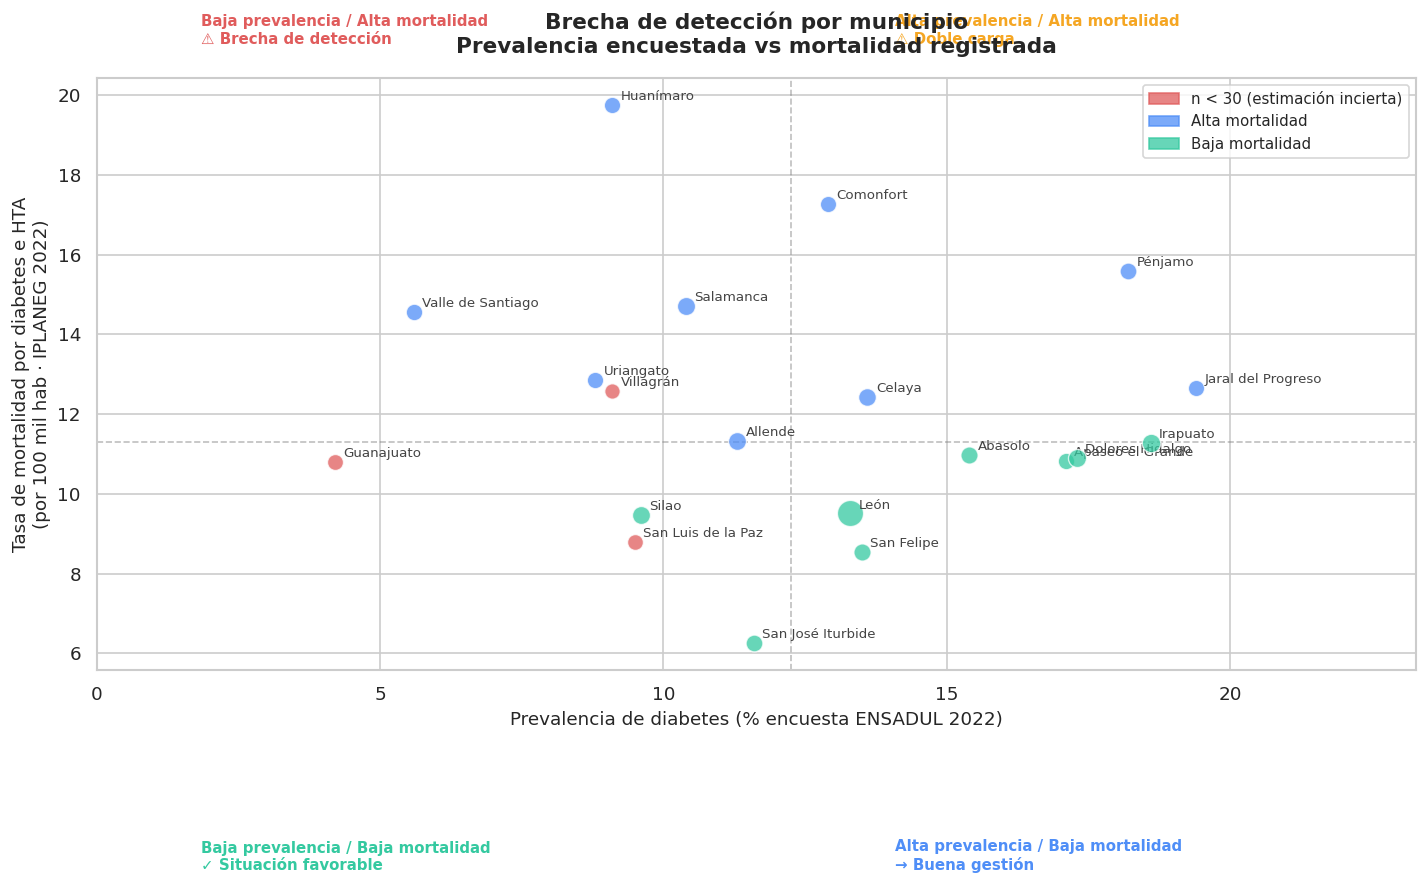


Municipios en cuadrante 'Brecha de detección' (alta mort., baja prev.):
    municipio_obs  n  diabetes_pct  mort_diab_hta_2022  pobreza_pct_2020
        Huanímaro 33           9.1           19.760056         49.421731
        Salamanca 77          10.4           14.717237         37.084103
          Allende 71          11.3           11.326815         43.466392
        Uriangato 34           8.8           12.856817         55.328207
Valle de Santiago 36           5.6           14.558226         46.998982
        Villagrán 11           9.1           12.582481         36.957889


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

for _, row in panel.iterrows():
    x = row['diabetes_pct']
    y = row['mort_diab_hta_2022']
    size = 80 + row['n'] * 0.5
    color = '#e05c5c' if not row['muestra_suficiente'] else (
        '#4f8ef7' if y > panel['mort_diab_hta_2022'].median() else '#34c9a0')
    ax.scatter(x, y, s=size, color=color, alpha=0.75, edgecolors='white', linewidth=0.8, zorder=3)
    ax.annotate(row['municipio_obs'],
                xy=(x, y), xytext=(5, 3), textcoords='offset points',
                fontsize=8, color='#444')

# Quadrant lines at medians
mx = panel['diabetes_pct'].median()
my = panel['mort_diab_hta_2022'].median()
ax.axvline(mx, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(my, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Quadrant labels
ax.text(mx*0.15, my*1.95, 'Baja prevalencia / Alta mortalidad\n⚠ Brecha de detección',
        fontsize=9, color='#e05c5c', fontweight='bold', va='top')
ax.text(mx*1.15, my*1.95, 'Alta prevalencia / Alta mortalidad\n⚠ Doble carga',
        fontsize=9, color='#f5a623', fontweight='bold', va='top')
ax.text(mx*0.15, my*0.05, 'Baja prevalencia / Baja mortalidad\n✓ Situación favorable',
        fontsize=9, color='#34c9a0', fontweight='bold')
ax.text(mx*1.15, my*0.05, 'Alta prevalencia / Baja mortalidad\n→ Buena gestión',
        fontsize=9, color='#4f8ef7', fontweight='bold')

ax.set_xlabel('Prevalencia de diabetes (% encuesta ENSADUL 2022)', fontsize=11)
ax.set_ylabel('Tasa de mortalidad por diabetes e HTA\n(por 100 mil hab · IPLANEG 2022)', fontsize=11)
ax.set_title('Brecha de detección por municipio\nPrevalencia encuestada vs mortalidad registrada',
             fontsize=13, fontweight='bold', pad=15)

patches = [
    mpatches.Patch(color='#e05c5c', alpha=0.75, label='n < 30 (estimación incierta)'),
    mpatches.Patch(color='#4f8ef7', alpha=0.75, label='Alta mortalidad'),
    mpatches.Patch(color='#34c9a0', alpha=0.75, label='Baja mortalidad'),
]
ax.legend(handles=patches, loc='upper right', fontsize=9)
ax.set_xlim(0, panel['diabetes_pct'].max()*1.2)

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/brecha_deteccion.png', bbox_inches='tight')
plt.show()

print("\nMunicipios en cuadrante 'Brecha de detección' (alta mort., baja prev.):")
brecha = panel[(panel['mort_diab_hta_2022'] > my) & (panel['diabetes_pct'] < mx)]
print(brecha[['municipio_obs','n','diabetes_pct','mort_diab_hta_2022','pobreza_pct_2020']].to_string(index=False))

---
## 3. Pobreza y marginación vs carga de enfermedad

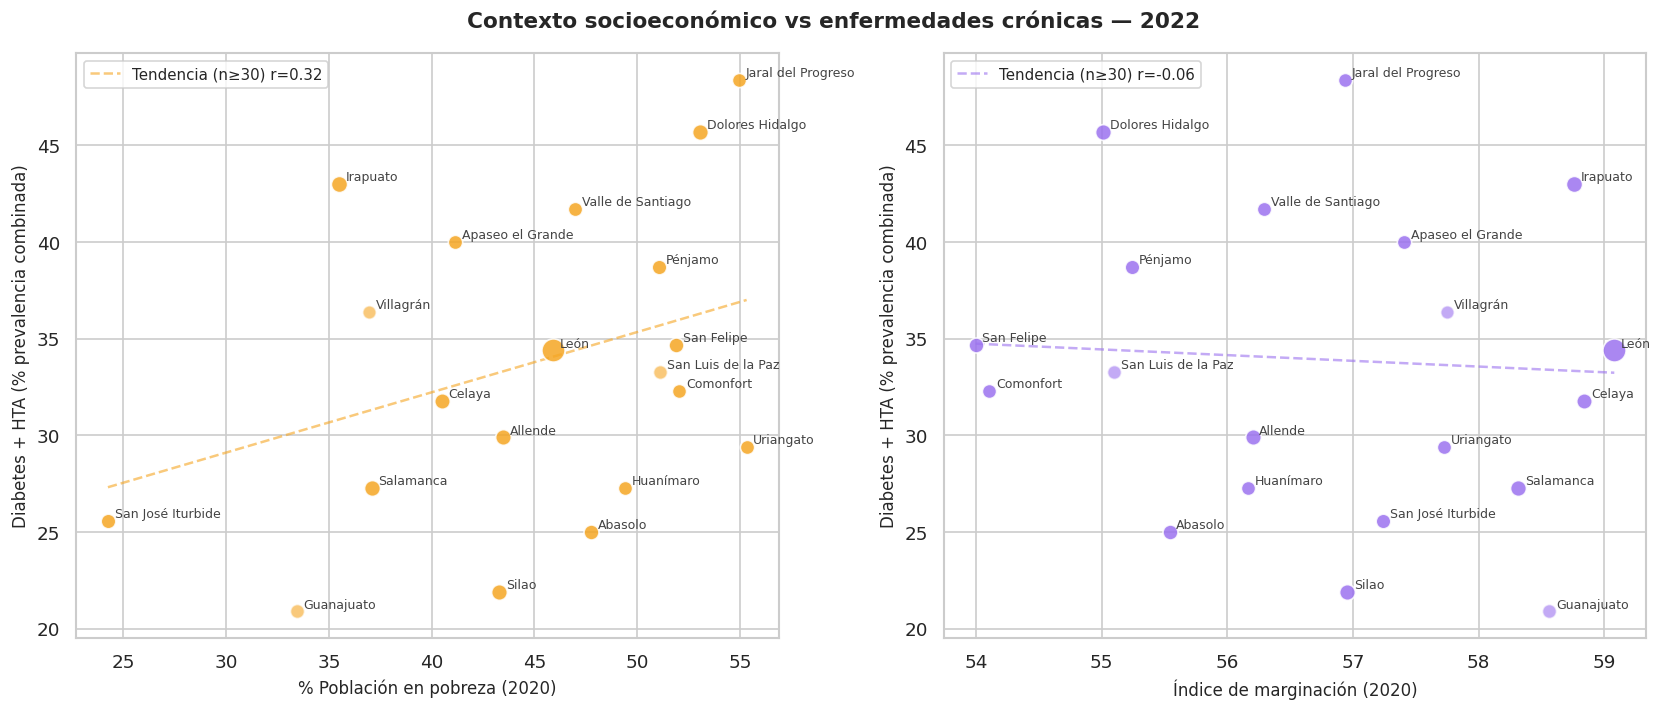

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Contexto socioeconómico vs enfermedades crónicas — 2022', fontsize=13, fontweight='bold')

for ax, (xcol, xlabel, color) in zip(axes, [
    ('pobreza_pct_2020',      '% Población en pobreza (2020)', '#f5a623'),
    ('idx_marginacion_2020',  'Índice de marginación (2020)',  '#9b72ef'),
]):
    for _, row in panel.iterrows():
        x = row[xcol]
        y = row['diabetes_pct'] + row['hta_pct']
        size = 60 + row['n'] * 0.4
        alpha = 0.6 if not row['muestra_suficiente'] else 0.85
        ax.scatter(x, y, s=size, color=color, alpha=alpha, edgecolors='white', zorder=3)
        ax.annotate(row['municipio_obs'], xy=(x, y), xytext=(4,2),
                    textcoords='offset points', fontsize=7.5, color='#444')

    # Trend line (only n>=30)
    sub = panel[panel['muestra_suficiente']]
    m, b = np.polyfit(sub[xcol], sub['diabetes_pct']+sub['hta_pct'], 1)
    xr = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
    ax.plot(xr, m*xr+b, color=color, linestyle='--', alpha=0.6, linewidth=1.5,
            label=f'Tendencia (n≥30) r={sub[xcol].corr(sub["diabetes_pct"]+sub["hta_pct"]):.2f}')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Diabetes + HTA (% prevalencia combinada)', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/pobreza_enfermedad.png', bbox_inches='tight')
plt.show()

---
## 4. Capacidad hospitalaria vs carga de enfermedad

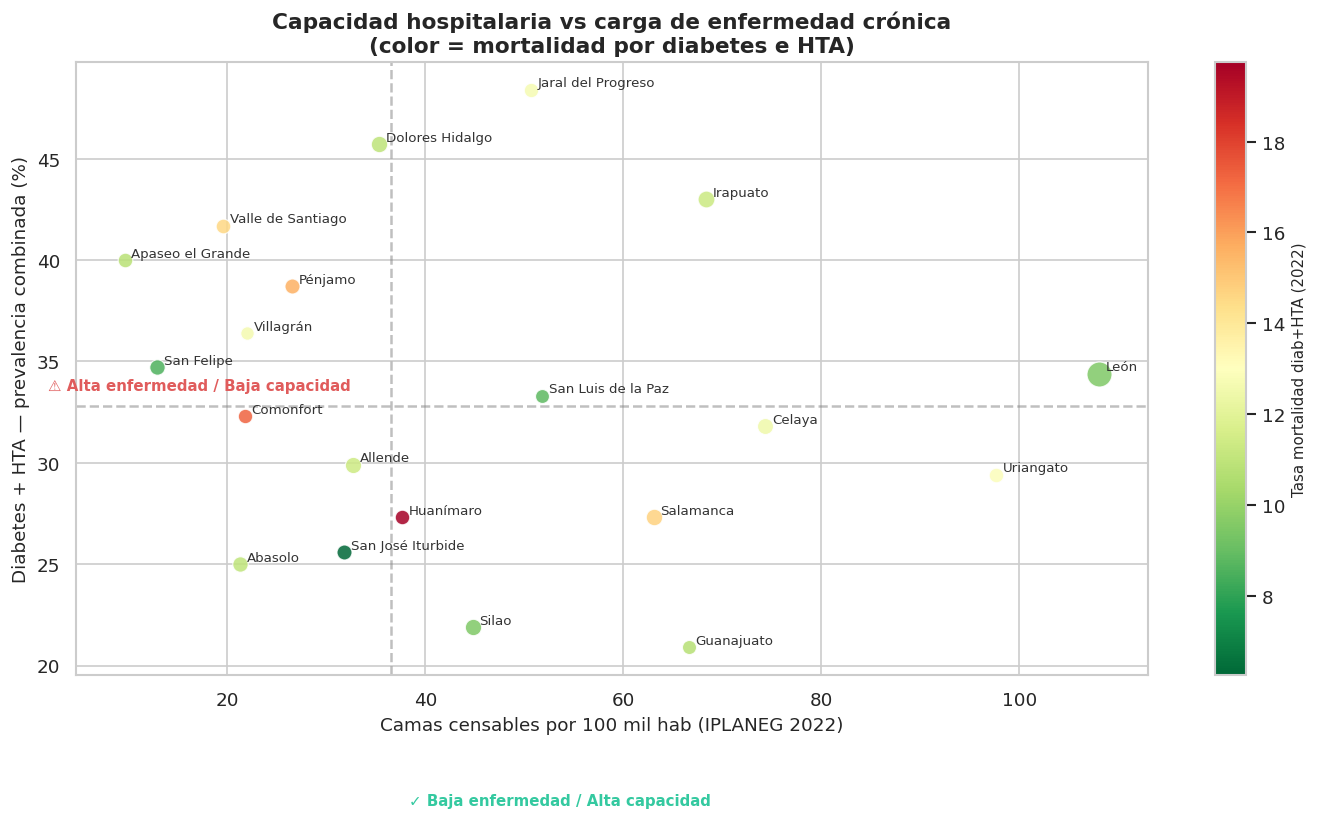

Municipios con alta carga Y baja capacidad (cuadrante crítico):
    municipio_obs  n  diabetes_pct  hta_pct  camas_x100k_2022  mort_diab_hta_2022
 Apaseo el Grande 35          17.1     22.9          9.617311           10.819475
  Dolores Hidalgo 75          17.3     28.4         35.332776           10.894273
          Pénjamo 44          18.2     20.5         26.511469           15.591269
       San Felipe 52          13.5     21.2         12.893348            8.541843
Valle de Santiago 36           5.6     36.1         19.585058           14.558226
        Villagrán 11           9.1     27.3         21.946188           12.582481


In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

# Color by mortality
norm = plt.Normalize(panel['mort_diab_hta_2022'].min(), panel['mort_diab_hta_2022'].max())
cmap = plt.cm.RdYlGn_r

for _, row in panel.iterrows():
    x = row['camas_x100k_2022']
    y = row['diabetes_pct'] + row['hta_pct']
    color = cmap(norm(row['mort_diab_hta_2022']))
    size = 60 + row['n']*0.5
    ax.scatter(x, y, s=size, color=color, alpha=0.85, edgecolors='white', linewidth=0.7, zorder=3)
    ax.annotate(row['municipio_obs'], xy=(x, y), xytext=(4,2),
                textcoords='offset points', fontsize=8, color='#333')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Tasa mortalidad diab+HTA (2022)', fontsize=9)

# Median lines
mx = panel['camas_x100k_2022'].median()
my = (panel['diabetes_pct']+panel['hta_pct']).median()
ax.axvline(mx, color='gray', linestyle='--', alpha=0.5)
ax.axhline(my, color='gray', linestyle='--', alpha=0.5)

ax.text(mx*0.05, my*1.02, '⚠ Alta enfermedad / Baja capacidad', fontsize=9,
        color='#e05c5c', fontweight='bold', va='bottom')
ax.text(mx*1.05, my*0.40, '✓ Baja enfermedad / Alta capacidad', fontsize=9,
        color='#34c9a0', fontweight='bold')

ax.set_xlabel('Camas censables por 100 mil hab (IPLANEG 2022)', fontsize=11)
ax.set_ylabel('Diabetes + HTA — prevalencia combinada (%)', fontsize=11)
ax.set_title('Capacidad hospitalaria vs carga de enfermedad crónica\n(color = mortalidad por diabetes e HTA)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/capacidad_vs_enfermedad.png', bbox_inches='tight')
plt.show()

print("Municipios con alta carga Y baja capacidad (cuadrante crítico):")
critico = panel[(panel['camas_x100k_2022'] < mx) &
                ((panel['diabetes_pct']+panel['hta_pct']) > my)]
print(critico[['municipio_obs','n','diabetes_pct','hta_pct','camas_x100k_2022','mort_diab_hta_2022']].to_string(index=False))

---
## 5. Tendencia de mortalidad por municipio (2020–2022)

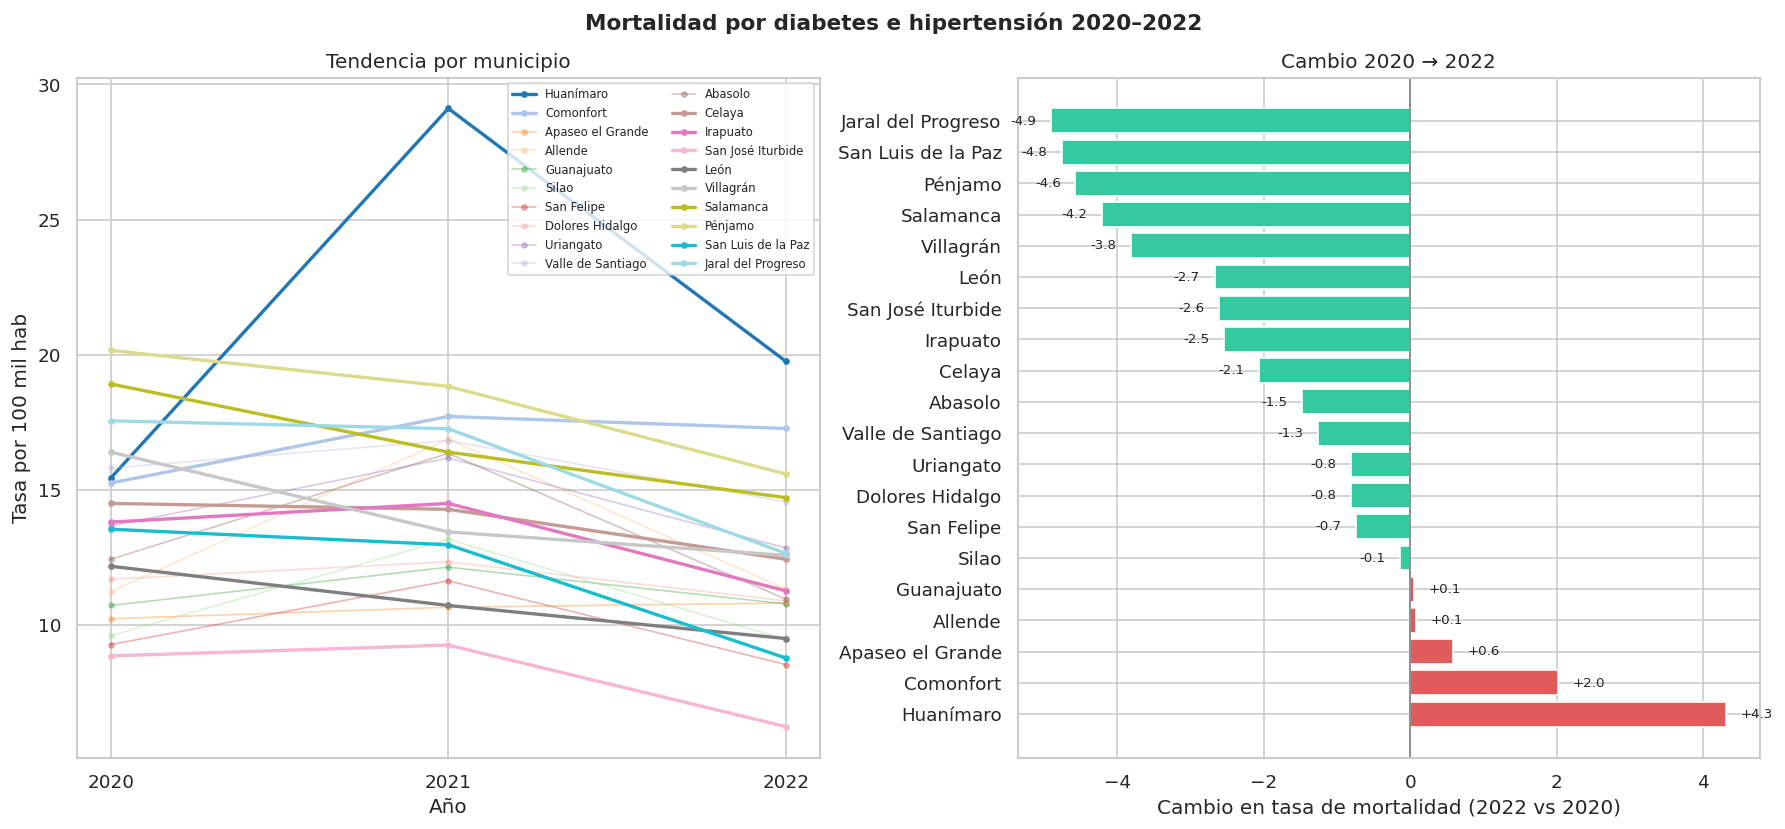

In [7]:
# Mortality trend per municipality using full IPLANEG data
mort_cols = ['municipio_obs','mort_diab_hta_2020','mort_diab_hta_2021','mort_diab_hta_2022']
mort_trend = panel[mort_cols].copy()
mort_trend['delta_2020_2022'] = mort_trend['mort_diab_hta_2022'] - mort_trend['mort_diab_hta_2020']
mort_trend = mort_trend.sort_values('delta_2020_2022', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Mortalidad por diabetes e hipertensión 2020–2022', fontsize=13, fontweight='bold')

# Left: trends per municipality
ax = axes[0]
years = [2020, 2021, 2022]
colors_trend = plt.cm.tab20.colors
for i, (_, row) in enumerate(mort_trend.iterrows()):
    vals = [row['mort_diab_hta_2020'], row['mort_diab_hta_2021'], row['mort_diab_hta_2022']]
    alpha = 1.0 if row['delta_2020_2022'] > 2 or row['delta_2020_2022'] < -2 else 0.35
    lw = 2 if abs(row['delta_2020_2022']) > 2 else 1
    ax.plot(years, vals, marker='o', markersize=3, linewidth=lw,
            color=colors_trend[i % 20], alpha=alpha, label=row['municipio_obs'])
ax.set_xlabel('Año'); ax.set_ylabel('Tasa por 100 mil hab')
ax.set_title('Tendencia por municipio')
ax.set_xticks(years)
ax.legend(fontsize=7, ncol=2, loc='upper right')

# Right: delta bar chart
ax = axes[1]
colors_bar = ['#e05c5c' if v > 0 else '#34c9a0' for v in mort_trend['delta_2020_2022']]
bars = ax.barh(mort_trend['municipio_obs'], mort_trend['delta_2020_2022'],
               color=colors_bar, edgecolor='white')
ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel('Cambio en tasa de mortalidad (2022 vs 2020)')
ax.set_title('Cambio 2020 → 2022')
for bar, val in zip(bars, mort_trend['delta_2020_2022']):
    ax.text(val + (0.2 if val >= 0 else -0.2), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/mortalidad_tendencia.png', bbox_inches='tight')
plt.show()

---
## 6. Matriz de priorización de intervención

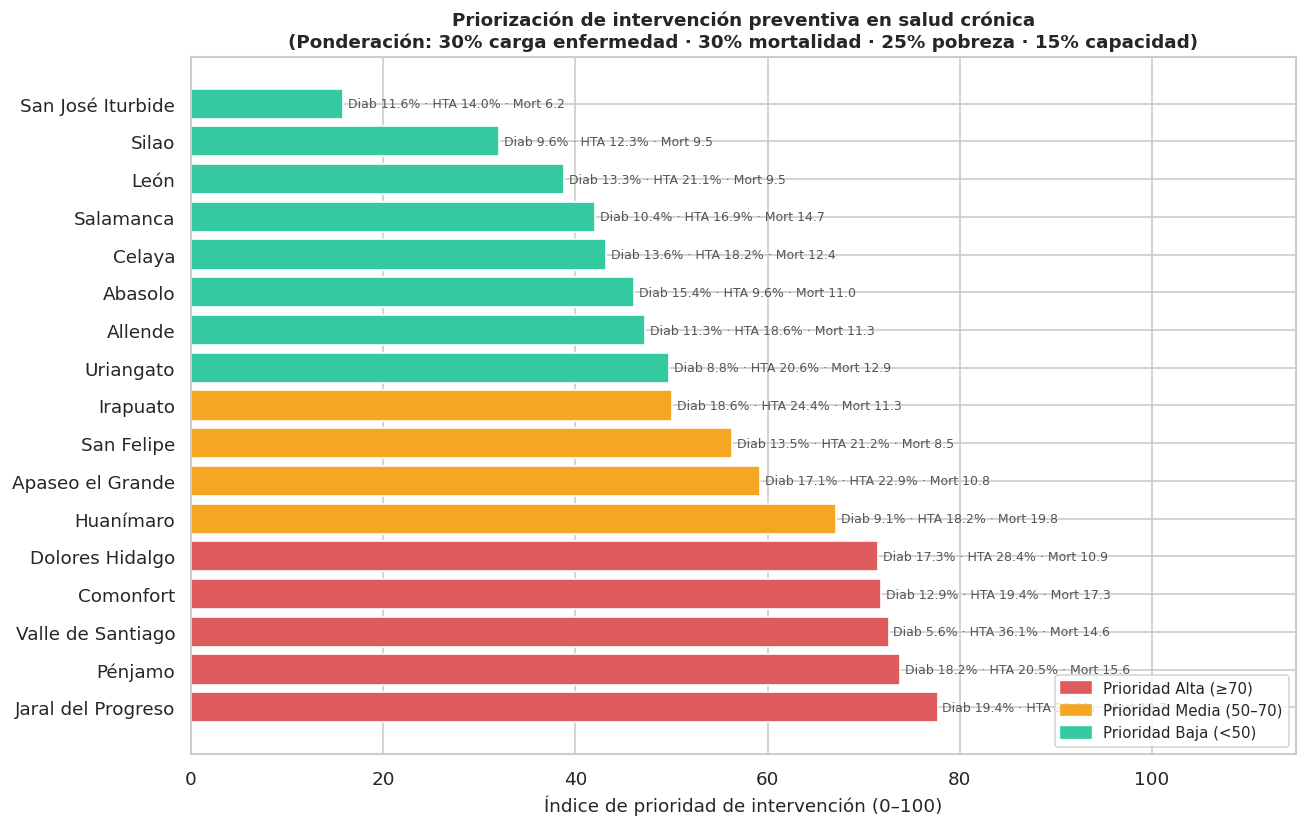


=== Municipios de ALTA PRIORIDAD ===
     municipio_obs  prioridad  diabetes_pct  hta_pct  mort_diab_hta_2022  pobreza_pct_2020  camas_x100k_2022
Jaral del Progreso       77.7          19.4     29.0           12.654704         54.972118         50.618815
           Pénjamo       73.8          18.2     20.5           15.591269         51.080979         26.511469
 Valle de Santiago       72.6           5.6     36.1           14.558226         46.998982         19.585058
         Comonfort       71.8          12.9     19.4           17.276165         52.051215         21.746222
   Dolores Hidalgo       71.5          17.3     28.4           10.894273         53.057693         35.332776


In [8]:
# Composite priority score:
# High = high disease burden + high poverty + low healthcare capacity + high mortality
# Normalize each 0-100, then average

def norm_col(s, higher_is_worse=True):
    mn, mx = s.min(), s.max()
    n = (s - mn) / (mx - mn) * 100 if mx > mn else pd.Series(50, index=s.index)
    return n if higher_is_worse else 100 - n

sub = panel[panel['muestra_suficiente']].copy()

sub['score_enfermedad']    = norm_col(sub['diabetes_pct'] + sub['hta_pct'])
sub['score_mortalidad']    = norm_col(sub['mort_diab_hta_2022'])
sub['score_pobreza']       = norm_col(sub['pobreza_pct_2020'])
sub['score_sin_capacidad'] = norm_col(sub['camas_x100k_2022'], higher_is_worse=False)

# Weighted composite
sub['prioridad'] = (
    sub['score_enfermedad']    * 0.30 +
    sub['score_mortalidad']    * 0.30 +
    sub['score_pobreza']       * 0.25 +
    sub['score_sin_capacidad'] * 0.15
).round(1)

sub_sorted = sub.sort_values('prioridad', ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))

bar_colors = ['#e05c5c' if v >= 70 else '#f5a623' if v >= 50 else '#34c9a0'
              for v in sub_sorted['prioridad']]
bars = ax.barh(sub_sorted['municipio_obs'], sub_sorted['prioridad'],
               color=bar_colors, edgecolor='white')
ax.set_xlabel('Índice de prioridad de intervención (0–100)', fontsize=11)
ax.set_title('Priorización de intervención preventiva en salud crónica\n'
             '(Ponderación: 30% carga enfermedad · 30% mortalidad · 25% pobreza · 15% capacidad)',
             fontsize=11, fontweight='bold')

for bar, row in zip(bars, sub_sorted.itertuples()):
    label = f"Diab {row.diabetes_pct}% · HTA {row.hta_pct}% · Mort {row.mort_diab_hta_2022:.1f}"
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=7.5, color='#555')

ax.set_xlim(0, 115)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e05c5c', label='Prioridad Alta (≥70)'),
    Patch(color='#f5a623', label='Prioridad Media (50–70)'),
    Patch(color='#34c9a0', label='Prioridad Baja (<50)'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/matriz_priorizacion.png', bbox_inches='tight')
plt.show()

print("\n=== Municipios de ALTA PRIORIDAD ===")
print(sub_sorted[sub_sorted['prioridad']>=70][
    ['municipio_obs','prioridad','diabetes_pct','hta_pct',
     'mort_diab_hta_2022','pobreza_pct_2020','camas_x100k_2022']].to_string(index=False))

---
## 7. Guardar panel enriquecido

In [9]:
# Add priority score to full panel
panel_out = panel.copy()
priority_map = sub.set_index('municipio_obs')['prioridad'].to_dict()
panel_out['prioridad_intervencion'] = panel_out['municipio_obs'].map(priority_map)
panel_out.to_csv(BASE + 'municipios_GTO_panel.csv', index=False)

print(f"Panel enriquecido guardado → {BASE}municipios_GTO_panel.csv")
print(f"Shape: {panel_out.shape}")
print("\nColumnas nuevas:")
new_cols = [c for c in panel_out.columns if c not in panel.columns or c == 'prioridad_intervencion']
print(new_cols)

Panel enriquecido guardado → ../data/processed/municipios_GTO_panel.csv
Shape: (20, 40)

Columnas nuevas:
['prioridad_intervencion']


---
## 8. Resumen ejecutivo

In [10]:
print('='*65)
print('ANÁLISIS DE CONTEXTO MUNICIPAL — OBSERVATORIO GTO + ENSADUL 2022')
print('='*65)

high_mort = panel.nlargest(3,'mort_diab_hta_2022')[['municipio_obs','mort_diab_hta_2022']]
low_cap   = panel.nsmallest(3,'camas_x100k_2022')[['municipio_obs','camas_x100k_2022']]
high_pob  = panel.nlargest(3,'pobreza_pct_2020')[['municipio_obs','pobreza_pct_2020']]

print("\n Mayor mortalidad diab+HTA (por 100k hab, 2022):")
for _, r in high_mort.iterrows():
    print(f"   {r['municipio_obs']}: {r['mort_diab_hta_2022']:.1f}")

print("\n Menor capacidad hospitalaria (camas/100k, 2022):")
for _, r in low_cap.iterrows():
    print(f"   {r['municipio_obs']}: {r['camas_x100k_2022']:.1f}")

print("\n Mayor pobreza (%, 2020):")
for _, r in high_pob.iterrows():
    print(f"   {r['municipio_obs']}: {r['pobreza_pct_2020']:.1f}%")

if 'prioridad_intervencion' in panel_out.columns:
    top5 = panel_out.dropna(subset=['prioridad_intervencion']).nlargest(5,'prioridad_intervencion')
    print("\n TOP 5 municipios — prioridad de intervención:")
    for _, r in top5.iterrows():
        print(f"   {r['municipio_obs']}: {r['prioridad_intervencion']:.0f}/100")
print('='*65)

ANÁLISIS DE CONTEXTO MUNICIPAL — OBSERVATORIO GTO + ENSADUL 2022

 Mayor mortalidad diab+HTA (por 100k hab, 2022):
   Huanímaro: 19.8
   Comonfort: 17.3
   Pénjamo: 15.6

 Menor capacidad hospitalaria (camas/100k, 2022):
   Apaseo el Grande: 9.6
   San Felipe: 12.9
   Valle de Santiago: 19.6

 Mayor pobreza (%, 2020):
   Uriangato: 55.3%
   Jaral del Progreso: 55.0%
   Dolores Hidalgo: 53.1%

 TOP 5 municipios — prioridad de intervención:
   Jaral del Progreso: 78/100
   Pénjamo: 74/100
   Valle de Santiago: 73/100
   Comonfort: 72/100
   Dolores Hidalgo: 72/100
